<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
">
    <img 
        src="https://raw.githubusercontent.com/sarasadatnasr/Machine_Learning_Final_Project/728689a356aa43073d6552462b8ba6ab8aca9218/Logo/ut-logo.png"
        alt="University Logo"
        style="height: 120px;"
    >
    <div style="
        text-align: center;
        font-family: 'Segoe UI', Arial, sans-serif;
        color: #222;
        line-height: 1.4;
    ">
        <h1 style="margin: 0; font-size: 32px; color: #2e98c6;">Machine Learning - Final Project</h1>
        <h3 style="margin: 6px 0 12px; font-weight: 500; color: #555;">Classification</h3>
        <p style="margin: 0; font-size: 15px;">
            <strong>Sara Sadat Nasr Azadani</strong> ·
            <strong>Alireza Farshi</strong> ·
            <strong>Saeid Rezaie</strong>
        </p>
    </div>
    <img 
        src="https://raw.githubusercontent.com/sarasadatnasr/Machine_Learning_Final_Project/7dab869a805ff296327c1fdcbc6954e3478073e7/Logo/co-w-9.png"
        alt="Faculty Logo"
        style="height: 120px;"
    >
</div>

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
📚Import Libraries
</div>

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import os
import warnings

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold
import time

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, confusion_matrix, classification_report,
                           roc_auc_score)

import joblib
import json
from datetime import datetime

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
🎨 Set Environments theme
</div>

In [70]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
📁 Load extracted features
</div>

In [71]:
print("Loading features...")
features_df = pd.read_csv('./Data_Cleaning_and_Feature_Extraction/audio_features.csv')
print(f"Dataset shape: {features_df.shape}")

# Add diagnostic: print column names to check for metadata
print("\nFeature columns (first 20):")
print(features_df.columns[:20].tolist())

# Function to extract speaker ID from filename
def extract_speaker_id(filename):
    # Remove augmentation suffix first
    clean_filename = filename.replace('_aug_0', '').replace('_aug_1', '').replace('_aug_2', '')
    
    # Try different patterns
    if '_' in clean_filename:
        # Pattern 1: speaker_sample format
        parts = clean_filename.split('_')
        if any(part.isdigit() for part in parts):
            for part in parts:
                if part.isdigit() and len(part) >= 2:
                    return part  # Return numeric ID
        # Return first part as speaker
        return parts[0]
    
    # If no underscore, use filename without extension
    return clean_filename.split('.')[0]

# Add speaker_id column
features_df['speaker_id'] = features_df['filename'].apply(extract_speaker_id)
print(f"\nUnique speakers detected: {features_df['speaker_id'].nunique()}")

# Check for duplicate/similar samples from augmentation
print("\nChecking for augmented samples...")
original_samples = features_df[~features_df['filename'].str.contains('_aug_')]
augmented_samples = features_df[features_df['filename'].str.contains('_aug_')]

print(f"Original samples: {len(original_samples)}")
print(f"Augmented samples: {len(augmented_samples)}")

# Create mapping between original and augmented samples
features_df['base_filename'] = features_df['filename'].str.replace(r'_aug_\d+$', '', regex=True)

# Prepare data - use only original samples for train/test split
original_features_df = features_df[~features_df['filename'].str.contains('_aug_')].copy()

print(f"\nUsing {len(original_features_df)} original samples for train/test split")

Loading features...
Dataset shape: (2848, 109)

Feature columns (first 20):
['zcr_mean', 'zcr_std', 'rms_mean', 'rms_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_bandwidth_mean', 'spectral_bandwidth_std', 'spectral_rolloff_mean', 'spectral_rolloff_std', 'mfcc_0_mean', 'mfcc_0_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std']

Unique speakers detected: 77

Checking for augmented samples...
Original samples: 712
Augmented samples: 2136

Using 712 original samples for train/test split


In [72]:
print("\nChecking for metadata columns in features...")
metadata_columns = ['filename', 'language', 'gender', 'speaker_id', 'base_filename']
potential_metadata_patterns = ['duration', 'sample_rate', 'num_samples', 'sr_', 'length_']

# Find and remove any columns that contain metadata
all_columns = original_features_df.columns.tolist()
feature_columns = []

for col in all_columns:
    is_metadata = False
    # Check if column is explicitly metadata
    if col in metadata_columns:
        is_metadata = True
    # Check for patterns indicating metadata
    for pattern in potential_metadata_patterns:
        if pattern in col.lower():
            print(f"  Removing metadata column: {col}")
            is_metadata = True
            break
    
    if not is_metadata and col not in ['language', 'gender', 'filename', 'speaker_id', 'base_filename']:
        # Check if column is numeric (should be a feature)
        if original_features_df[col].dtype in [np.float64, np.int64, np.float32, np.int32]:
            feature_columns.append(col)

print(f"\nSelected {len(feature_columns)} feature columns")
print(f"First 10 features: {feature_columns[:10]}")

X = original_features_df[feature_columns].copy()
y = original_features_df['language']
gender = original_features_df['gender']
speaker_ids = original_features_df['speaker_id']

# Encode labels
language_le = LabelEncoder()
gender_le = LabelEncoder()
speaker_le = LabelEncoder()

y_encoded = language_le.fit_transform(y)
gender_encoded = gender_le.fit_transform(gender)
speaker_encoded = speaker_le.fit_transform(speaker_ids)

print("\nEncoded labels:")
print("Languages:", dict(zip(language_le.classes_, range(len(language_le.classes_)))))
print("Genders:", dict(zip(gender_le.classes_, range(len(gender_le.classes_)))))
print(f"Unique speakers: {len(speaker_le.classes_)}")


Checking for metadata columns in features...

Selected 106 feature columns
First 10 features: ['zcr_mean', 'zcr_std', 'rms_mean', 'rms_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_bandwidth_mean', 'spectral_bandwidth_std', 'spectral_rolloff_mean', 'spectral_rolloff_std']

Encoded labels:
Languages: {'German': 0, 'Italian': 1, 'Korean': 2, 'Spanish': 3}
Genders: {'Female': 0, 'Male': 1}
Unique speakers: 77


<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
✂️ Train-Test Split with Stratification
</div>

In [73]:
def create_speaker_independent_split(X, y, speaker_ids, test_size=0.2, random_state=42):
    # Get unique speakers
    unique_speakers = np.unique(speaker_ids)
    
    # Split speakers (not samples)
    speaker_train, speaker_test = train_test_split(
        unique_speakers, 
        test_size=test_size, 
        random_state=random_state
    )
    
    # Get indices for training and testing
    train_idx = np.where(np.isin(speaker_ids, speaker_train))[0]
    test_idx = np.where(np.isin(speaker_ids, speaker_test))[0]
    
    # Split the data
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]
    speaker_train_ids = speaker_ids[train_idx]
    speaker_test_ids = speaker_ids[test_idx]
    
    # Create DataFrame for tracking samples
    train_df = pd.DataFrame({
        'index': train_idx,
        'speaker_id': speaker_train_ids
    })
    test_df = pd.DataFrame({
        'index': test_idx,
        'speaker_id': speaker_test_ids
    })
    
    return X_train, X_test, y_train, y_test, train_df, test_df


print("Creating speaker-independent train-test split...")
X_train, X_test, y_train, y_test, train_df, test_df = create_speaker_independent_split(
    X, y_encoded, speaker_encoded, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)} (speakers: {np.unique(train_df['speaker_id']).shape[0]})")
print(f"Testing set size: {len(X_test)} (speakers: {np.unique(test_df['speaker_id']).shape[0]})")

# Check for speaker overlap
train_speakers = set(train_df['speaker_id'])
test_speakers = set(test_df['speaker_id'])
common_speakers = train_speakers.intersection(test_speakers)
print(f"Speakers in both train and test (should be 0): {len(common_speakers)}")

if len(common_speakers) > 0:
    print("WARNING: Speaker leakage detected!")
    print(f"Common speakers: {common_speakers}")

# Check class distribution
print("\nClass distribution in training set:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(language_le.inverse_transform(unique_train), counts_train):
    print(f"{label}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nClass distribution in testing set:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for label, count in zip(language_le.inverse_transform(unique_test), counts_test):
    print(f"{label}: {count} ({count/len(y_test)*100:.1f}%)")

# Get actual sample indices for later use
train_indices = train_df['index'].values
test_indices = test_df['index'].values
train_samples = original_features_df.iloc[train_indices]
test_samples = original_features_df.iloc[test_indices]

print("\nAdding augmented data to training set (leakage-free)...")

# Get base filenames for training samples
train_base_filenames = set(train_samples['base_filename'])

# Find augmented samples that correspond to training base filenames
# BUT also ensure their speaker_id is in training speakers
train_speaker_names = set(train_samples['speaker_id'])

augmented_for_training = features_df[
    features_df['filename'].str.contains('_aug_') & 
    features_df['base_filename'].isin(train_base_filenames) &
    features_df['speaker_id'].isin(train_speaker_names)
]

print(f"Adding {len(augmented_for_training)} augmented samples to training set")

# Combine original training samples with their augmentations
X_train_aug = pd.concat([X_train, augmented_for_training[feature_columns]])
y_train_aug = np.concatenate([
    y_train, 
    language_le.transform(augmented_for_training['language'])
])

print(f"Final training set size: {len(X_train_aug)} (original: {len(X_train)}, augmented: {len(augmented_for_training)})")

# Verify no augmented test samples could leak
test_base_filenames = set(test_samples['base_filename'])
test_speaker_names = set(test_samples['speaker_id'])

augmented_test_leak = features_df[
    features_df['filename'].str.contains('_aug_') & 
    features_df['base_filename'].isin(test_base_filenames) &
    features_df['speaker_id'].isin(test_speaker_names)
]

print(f"\nData leakage check:")
print(f"Augmented samples that would leak to test: {len(augmented_test_leak)}")

# Double-check: ensure no test speakers in augmented training
augmented_training_speakers = set(augmented_for_training['speaker_id'])
leak_speakers = augmented_training_speakers.intersection(test_speaker_names)
print(f"Speakers in both augmented training and test: {len(leak_speakers)}")

# Clean test set (ensure no augmentation)
X_test_clean = X_test.copy()
y_test_clean = y_test.copy()

Creating speaker-independent train-test split...
Training set size: 539 (speakers: 61)
Testing set size: 173 (speakers: 16)
Speakers in both train and test (should be 0): 0

Class distribution in training set:
German: 163 (30.2%)
Italian: 109 (20.2%)
Korean: 97 (18.0%)
Spanish: 170 (31.5%)

Class distribution in testing set:
German: 9 (5.2%)
Italian: 71 (41.0%)
Korean: 83 (48.0%)
Spanish: 10 (5.8%)

Adding augmented data to training set (leakage-free)...
Adding 1617 augmented samples to training set
Final training set size: 2156 (original: 539, augmented: 1617)

Data leakage check:
Augmented samples that would leak to test: 519
Speakers in both augmented training and test: 0


<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
🤖 Feature Preprocessing
</div>

In [74]:
print("\nFeature quality analysis:")
print(f"Total features: {X_train_aug.shape[1]}")
print(f"Training samples: {X_train_aug.shape[0]}")
print(f"Test samples: {X_test_clean.shape[0]}")

# Check for constant features
constant_features = X_train_aug.columns[X_train_aug.nunique() == 1].tolist()
print(f"Constant features (removing): {len(constant_features)}")
if constant_features:
    X_train_aug = X_train_aug.drop(columns=constant_features)
    X_test_clean = X_test_clean.drop(columns=constant_features)
    print(f"  Removed: {constant_features[:5]}...")  # Show first 5

# Check for NaN values
nan_count_train = X_train_aug.isna().sum().sum()
nan_count_test = X_test_clean.isna().sum().sum()
print(f"NaN values in train: {nan_count_train}")
print(f"NaN values in test: {nan_count_test}")

if nan_count_train > 0:
    X_train_aug = X_train_aug.fillna(X_train_aug.mean())
if nan_count_test > 0:
    X_test_clean = X_test_clean.fillna(X_train_aug.mean())  # Use training mean

# Standardize features (fit ONLY on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_aug)
X_test_scaled = scaler.transform(X_test_clean)

print(f"\nFeature standardization complete")
print(f"Training mean after scaling: {X_train_scaled.mean():.6f} (should be ~0)")
print(f"Training std after scaling: {X_train_scaled.std():.6f} (should be ~1)")

# Dimensionality Reduction with PCA (fit ONLY on training data)
pca = PCA(n_components=0.95)  # Keep 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"\nPCA dimensionality reduction:")
print(f"Original number of features: {X_train_aug.shape[1]}")
print(f"Number of PCA components (95% variance): {X_train_pca.shape[1]}")


Feature quality analysis:
Total features: 106
Training samples: 2156
Test samples: 173
Constant features (removing): 0
NaN values in train: 0
NaN values in test: 0

Feature standardization complete
Training mean after scaling: -0.000000 (should be ~0)
Training std after scaling: 1.000000 (should be ~1)

PCA dimensionality reduction:
Original number of features: 106
Number of PCA components (95% variance): 36


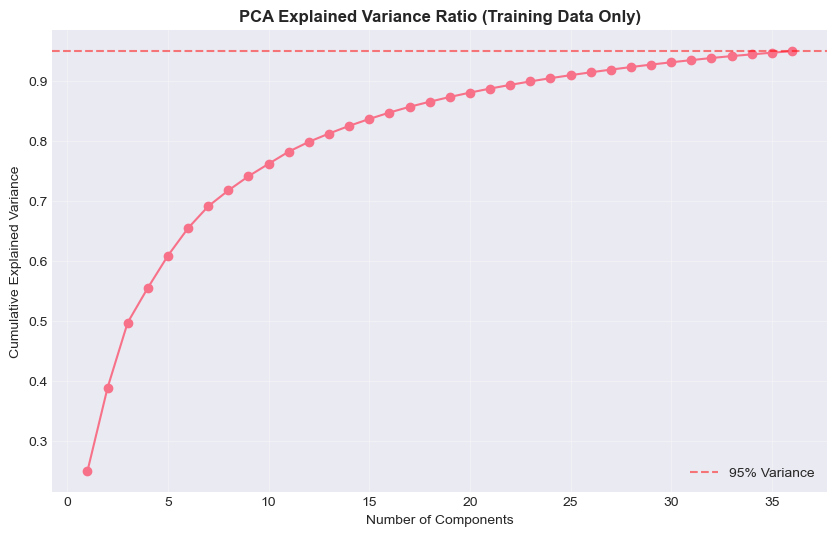

In [75]:
# Visualize explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='95% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance Ratio (Training Data Only)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('./Classification/pca_explained_variance_leakage_free.png', dpi=300, bbox_inches='tight')
plt.show()


LDA visualization (original training samples only)...


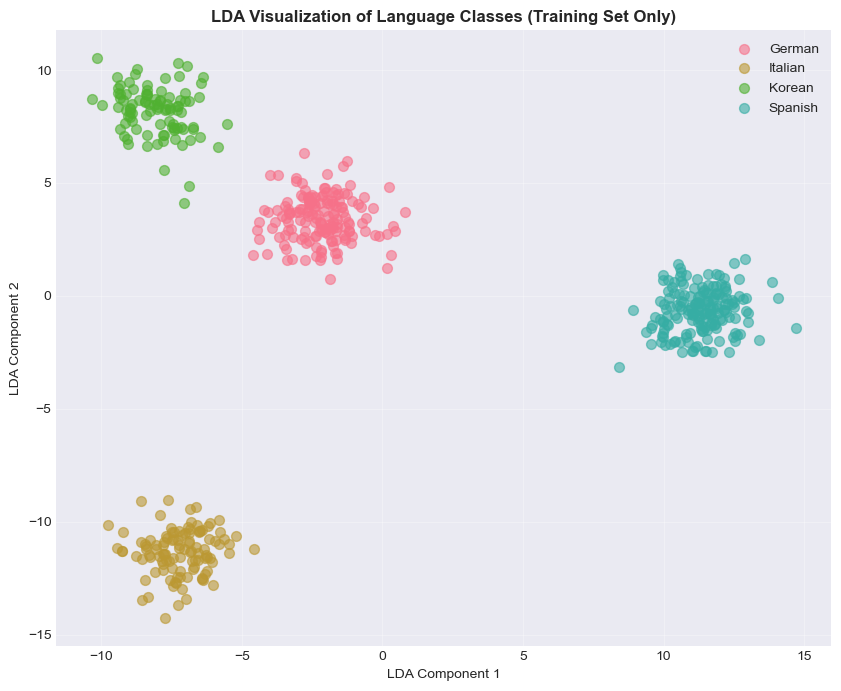

In [76]:
# Apply LDA for visualization (use only original training samples)
print("\nLDA visualization (original training samples only)...")
X_train_original_scaled = scaler.transform(X_train)  # Scale only original training
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_original_scaled, y_train)

plt.figure(figsize=(10, 8))
for i, label in enumerate(language_le.classes_):
    indices = y_train == language_le.transform([label])[0]
    plt.scatter(X_train_lda[indices, 0], X_train_lda[indices, 1],
               label=label, alpha=0.6, s=50)

plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.title('LDA Visualization of Language Classes (Training Set Only)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('./Classification/lda_visualization_leakage_free.png', dpi=300, bbox_inches='tight')
plt.show()

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
🧑‍🏫 Model Training
</div>

In [77]:
models = {
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'Support Vector Machine': SVC(probability=True, random_state=42, C=1.0, kernel='rbf'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, max_features='sqrt'),
    'Multi-Layer Perceptron': MLPClassifier(hidden_layer_sizes=(100, 50), random_state=42, 
                                          max_iter=1000, alpha=0.01, early_stopping=True),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0, solver='saga'),
    'Naive Bayes': GaussianNB()
}

# First, perform rigorous cross-validation
print("="*60)
print("RIGOROUS 5-FOLD CROSS-VALIDATION ON TRAINING DATA")
print("="*60)

cv_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    fold_scores = []
    fold_times = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_pca, y_train_aug), 1):
        start_time = time.time()
        
        # Split fold data
        X_fold_train, X_fold_val = X_train_pca[train_idx], X_train_pca[val_idx]
        y_fold_train, y_fold_val = y_train_aug[train_idx], y_train_aug[val_idx]
        
        # Train on fold
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_fold_train, y_fold_train)
        
        # Validate
        score = model_clone.score(X_fold_val, y_fold_val)
        fold_scores.append(score)
        fold_times.append(time.time() - start_time)
        
    cv_results[name] = {
        'mean_score': np.mean(fold_scores),
        'std_score': np.std(fold_scores),
        'mean_time': np.mean(fold_times),
        'scores': fold_scores
    }
    
    print(f"{name:25s}: CV Accuracy = {cv_results[name]['mean_score']:.4f} (±{cv_results[name]['std_score']:.4f})")

RIGOROUS 5-FOLD CROSS-VALIDATION ON TRAINING DATA
K-Nearest Neighbors      : CV Accuracy = 1.0000 (±0.0000)
Support Vector Machine   : CV Accuracy = 1.0000 (±0.0000)
Random Forest            : CV Accuracy = 0.9977 (±0.0015)
Multi-Layer Perceptron   : CV Accuracy = 0.9958 (±0.0043)
Decision Tree            : CV Accuracy = 0.9592 (±0.0111)
Logistic Regression      : CV Accuracy = 0.9986 (±0.0011)
Naive Bayes              : CV Accuracy = 0.9824 (±0.0050)


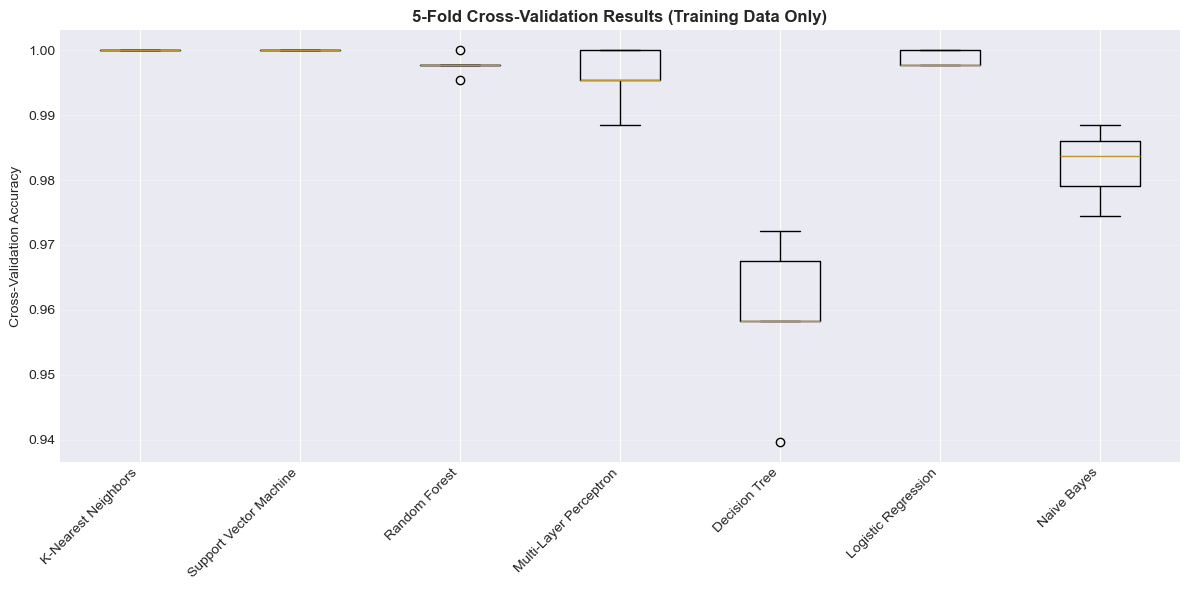

In [78]:
# Visualize CV results
plt.figure(figsize=(12, 6))
box_data = [cv_results[name]['scores'] for name in models.keys()]
plt.boxplot(box_data, labels=list(models.keys()))
plt.xticks(rotation=45, ha='right')
plt.ylabel('Cross-Validation Accuracy')
plt.title('5-Fold Cross-Validation Results (Training Data Only)', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('./Classification/cross_validation_leakage_free.png', dpi=300, bbox_inches='tight')
plt.show()

In [79]:
results = {}
training_times = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Record training time
    start_time = time.time()
    
    # Train on full training set
    model.fit(X_train_pca, y_train_aug)
    
    # Predict
    y_pred = model.predict(X_test_pca)
    y_pred_train = model.predict(X_train_pca)
    y_pred_proba = model.predict_proba(X_test_pca) if hasattr(model, 'predict_proba') else None
    
    # Calculate training time
    training_time = time.time() - start_time
    training_times[name] = training_time
    
    # Store results
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_pred_train': y_pred_train,
        'y_pred_proba': y_pred_proba,
        'cv_mean': cv_results[name]['mean_score'],
        'cv_std': cv_results[name]['std_score']
    }
    
    print(f"  Training time: {training_time:.2f} seconds")
    print(f"  CV Accuracy: {cv_results[name]['mean_score']:.4f} (±{cv_results[name]['std_score']:.4f})")



Training K-Nearest Neighbors...
  Training time: 0.02 seconds
  CV Accuracy: 1.0000 (±0.0000)

Training Support Vector Machine...
  Training time: 0.32 seconds
  CV Accuracy: 1.0000 (±0.0000)

Training Random Forest...
  Training time: 0.80 seconds
  CV Accuracy: 0.9977 (±0.0015)

Training Multi-Layer Perceptron...
  Training time: 0.27 seconds
  CV Accuracy: 0.9958 (±0.0043)

Training Decision Tree...
  Training time: 0.07 seconds
  CV Accuracy: 0.9592 (±0.0111)

Training Logistic Regression...
  Training time: 0.68 seconds
  CV Accuracy: 0.9986 (±0.0011)

Training Naive Bayes...
  Training time: 0.00 seconds
  CV Accuracy: 0.9824 (±0.0050)


<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
🧪 Comprehensive Model Evaluation
</div>

In [80]:
def calculate_metrics(y_true, y_pred, model_name, y_proba=None, classes=None):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }
    
    # Add AUC if probabilities are available
    if y_proba is not None and classes is not None and len(classes) > 1:
        try:
            # For multi-class, use one-vs-rest
            metrics['AUC'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
        except:
            metrics['AUC'] = np.nan
    
    return metrics

# Calculate metrics for all models
metrics_data = []

for name in results.keys():
    test_metrics = calculate_metrics(
        y_test_clean, results[name]['y_pred'], name,
        results[name]['y_pred_proba'], language_le.classes_
    )
    train_metrics = calculate_metrics(
        y_train_aug, results[name]['y_pred_train'], name
    )
    
    # Calculate generalization gap
    generalization_gap = train_metrics['Accuracy'] - test_metrics['Accuracy']
    
    # Determine overfitting risk
    if generalization_gap > 0.15:
        overfitting_risk = 'High'
    elif generalization_gap > 0.05:
        overfitting_risk = 'Medium'
    else:
        overfitting_risk = 'Low'
    
    # Store metrics as a dictionary
    model_metrics = {
        'Model': name,
        'CV Mean': results[name]['cv_mean'],
        'CV Std': results[name]['cv_std'],
        'Test Accuracy': test_metrics['Accuracy'],
        'Test F1-Score': test_metrics.get('F1-Score', np.nan),
        'Test AUC': test_metrics.get('AUC', np.nan),
        'Train Accuracy': train_metrics['Accuracy'],
        'Training Time': training_times[name],
        'Generalization Gap': generalization_gap,
        'Overfitting Risk': overfitting_risk
    }
    metrics_data.append(model_metrics)

# Create DataFrame with proper numeric types
metrics_df = pd.DataFrame(metrics_data)
metrics_df.set_index('Model', inplace=True)

# Convert numeric columns to float
numeric_columns = ['CV Mean', 'CV Std', 'Test Accuracy', 'Test F1-Score', 'Test AUC', 
                   'Train Accuracy', 'Training Time', 'Generalization Gap']
for col in numeric_columns:
    if col in metrics_df.columns:
        metrics_df[col] = pd.to_numeric(metrics_df[col], errors='coerce')


print("COMPREHENSIVE MODEL PERFORMANCE METRICS")
print(metrics_df.round(4))

COMPREHENSIVE MODEL PERFORMANCE METRICS
                        CV Mean  CV Std  Test Accuracy  Test F1-Score  \
Model                                                                   
K-Nearest Neighbors      1.0000  0.0000         0.9191         0.9320   
Support Vector Machine   1.0000  0.0000         0.9306         0.9393   
Random Forest            0.9977  0.0015         0.9133         0.9218   
Multi-Layer Perceptron   0.9958  0.0043         0.9595         0.9625   
Decision Tree            0.9592  0.0111         0.7977         0.8094   
Logistic Regression      0.9986  0.0011         0.9884         0.9887   
Naive Bayes              0.9824  0.0050         0.7110         0.6893   

                        Test AUC  Train Accuracy  Training Time  \
Model                                                             
K-Nearest Neighbors       0.9969          1.0000         0.0210   
Support Vector Machine    0.9995          1.0000         0.3180   
Random Forest             0.9944  

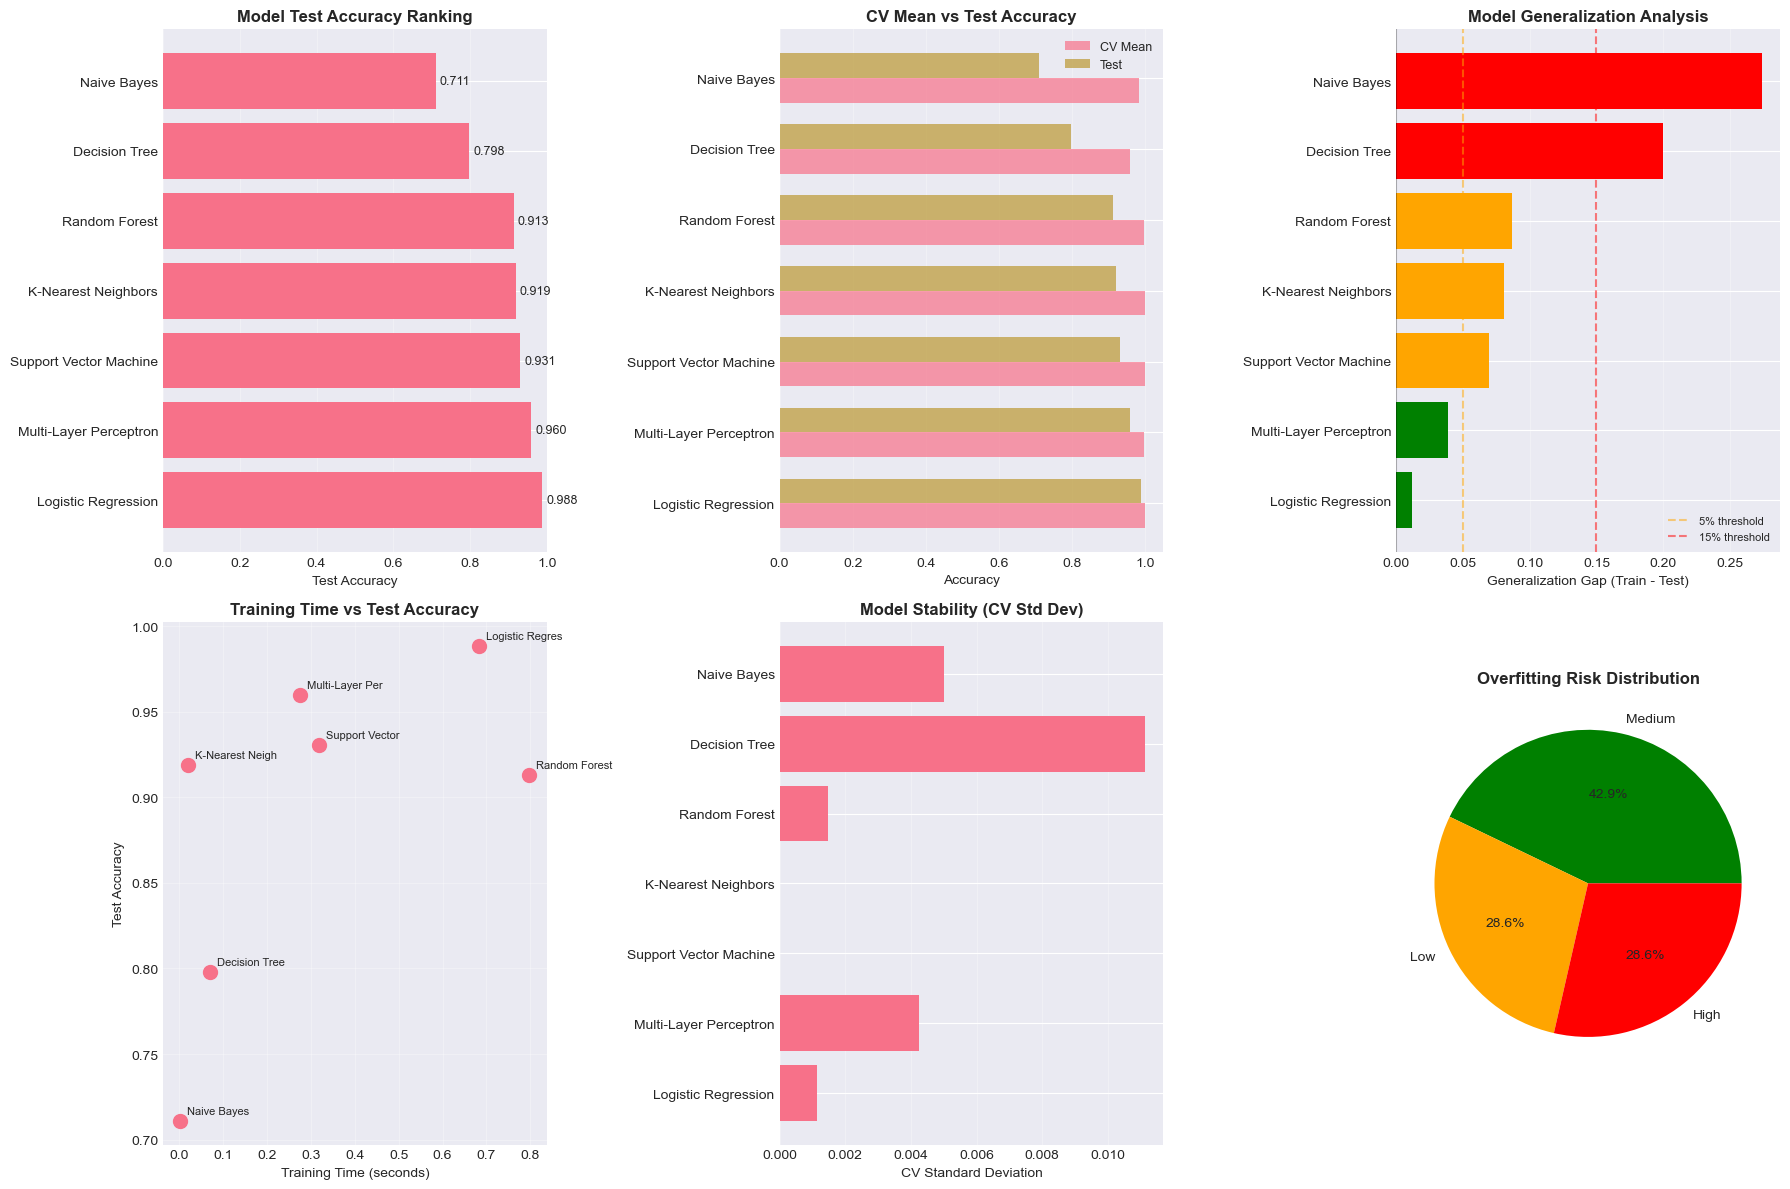

In [81]:
metrics_df = metrics_df.sort_values('Test Accuracy', ascending=False)

# Visualize model comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Test Accuracy comparison
axes[0,0].barh(range(len(metrics_df)), metrics_df['Test Accuracy'])
axes[0,0].set_yticks(range(len(metrics_df)))
axes[0,0].set_yticklabels(metrics_df.index)
axes[0,0].set_xlabel('Test Accuracy')
axes[0,0].set_title('Model Test Accuracy Ranking', fontweight='bold')
axes[0,0].grid(True, alpha=0.3, axis='x')
axes[0,0].set_xlim([0, 1])
for i, (idx, row) in enumerate(metrics_df.iterrows()):
    axes[0,0].text(row['Test Accuracy'] + 0.01, i, f"{row['Test Accuracy']:.3f}", 
                   va='center', fontsize=9)

# 2. CV vs Test Accuracy
x_pos = np.arange(len(metrics_df))
width = 0.35
axes[0,1].barh(x_pos - width/2, metrics_df['CV Mean'], width, label='CV Mean', alpha=0.7)
axes[0,1].barh(x_pos + width/2, metrics_df['Test Accuracy'], width, label='Test', alpha=0.7)
axes[0,1].set_yticks(x_pos)
axes[0,1].set_yticklabels(metrics_df.index)
axes[0,1].set_xlabel('Accuracy')
axes[0,1].set_title('CV Mean vs Test Accuracy', fontweight='bold')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.3, axis='x')

# 3. Generalization Gap
colors = ['red' if gap > 0.15 else 'orange' if gap > 0.05 else 'green' 
          for gap in metrics_df['Generalization Gap']]
axes[0,2].barh(range(len(metrics_df)), metrics_df['Generalization Gap'], color=colors)
axes[0,2].set_yticks(range(len(metrics_df)))
axes[0,2].set_yticklabels(metrics_df.index)
axes[0,2].set_xlabel('Generalization Gap (Train - Test)')
axes[0,2].set_title('Model Generalization Analysis', fontweight='bold')
axes[0,2].grid(True, alpha=0.3, axis='x')
axes[0,2].axvline(x=0, color='k', linestyle='-', alpha=0.3)
axes[0,2].axvline(x=0.05, color='orange', linestyle='--', alpha=0.5, label='5% threshold')
axes[0,2].axvline(x=0.15, color='red', linestyle='--', alpha=0.5, label='15% threshold')
axes[0,2].legend(fontsize=8)

# 4. Training Time vs Test Accuracy
axes[1,0].scatter(metrics_df['Training Time'], metrics_df['Test Accuracy'], s=100)
for model_name in metrics_df.index:
    axes[1,0].annotate(model_name[:15], 
                      (metrics_df.loc[model_name, 'Training Time'],
                       metrics_df.loc[model_name, 'Test Accuracy']),
                      xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_xlabel('Training Time (seconds)')
axes[1,0].set_ylabel('Test Accuracy')
axes[1,0].set_title('Training Time vs Test Accuracy', fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# 5. CV Std Deviation
axes[1,1].barh(range(len(metrics_df)), metrics_df['CV Std'])
axes[1,1].set_yticks(range(len(metrics_df)))
axes[1,1].set_yticklabels(metrics_df.index)
axes[1,1].set_xlabel('CV Standard Deviation')
axes[1,1].set_title('Model Stability (CV Std Dev)', fontweight='bold')
axes[1,1].grid(True, alpha=0.3, axis='x')

# 6. Overfitting Risk Summary
risk_counts = metrics_df['Overfitting Risk'].value_counts()
axes[1,2].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
              colors=['green', 'orange', 'red'])
axes[1,2].set_title('Overfitting Risk Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('./Classification/model_comparison_leakage_free.png', dpi=300, bbox_inches='tight')
plt.show()


<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
📈 Detailed Analysis of Top Model
</div>


Top 3 models based on Test Accuracy: ['Logistic Regression', 'Multi-Layer Perceptron', 'Support Vector Machine']


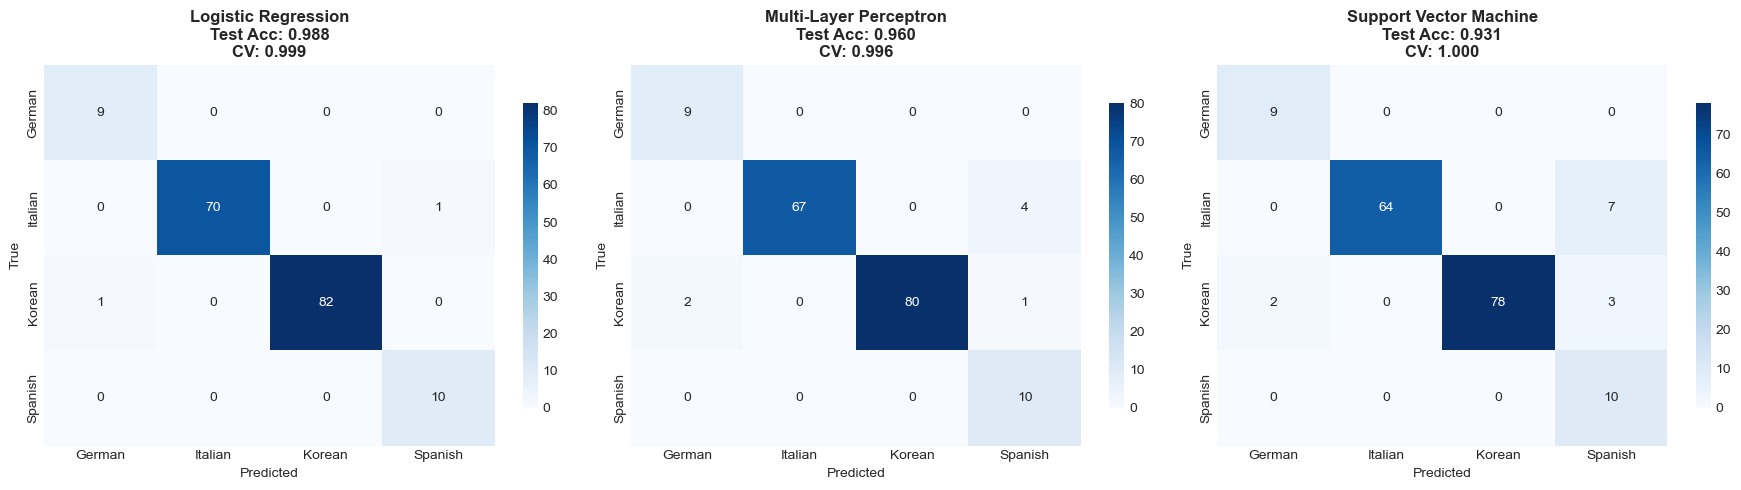

In [82]:
top_3_models = metrics_df.sort_values('Test Accuracy', ascending=False).head(3).index.tolist()
print(f"\nTop 3 models based on Test Accuracy: {top_3_models}")

# Confusion matrices for top 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model_name in enumerate(top_3_models):
    cm = confusion_matrix(y_test_clean, results[model_name]['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=language_le.classes_, yticklabels=language_le.classes_,
                ax=axes[idx], cbar_kws={'shrink': 0.8})
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
    axes[idx].set_title(f'{model_name}\nTest Acc: {metrics_df.loc[model_name, "Test Accuracy"]:.3f}\nCV: {metrics_df.loc[model_name, "CV Mean"]:.3f}',
                       fontweight='bold')

plt.tight_layout()
plt.savefig('./Classification/confusion_matrices_top3_leakage_free.png', dpi=300, bbox_inches='tight')
plt.show()


In [83]:
# Detailed classification reports
for model_name in top_3_models:
    print(f"\n{'='*60}")
    print(f"CLASSIFICATION REPORT: {model_name}")
    print('='*60)
    print(f"CV Accuracy: {metrics_df.loc[model_name, 'CV Mean']:.3f} (±{metrics_df.loc[model_name, 'CV Std']:.3f})")
    print(f"Test Accuracy: {metrics_df.loc[model_name, 'Test Accuracy']:.3f}")
    print(f"Generalization Gap: {metrics_df.loc[model_name, 'Generalization Gap']:.3f}")
    print(f"Overfitting Risk: {metrics_df.loc[model_name, 'Overfitting Risk']}")
    print('-'*60)
    print(classification_report(y_test_clean, results[model_name]['y_pred'], 
                               target_names=language_le.classes_))




CLASSIFICATION REPORT: Logistic Regression
CV Accuracy: 0.999 (±0.001)
Test Accuracy: 0.988
Generalization Gap: 0.012
Overfitting Risk: Low
------------------------------------------------------------
              precision    recall  f1-score   support

      German       0.90      1.00      0.95         9
     Italian       1.00      0.99      0.99        71
      Korean       1.00      0.99      0.99        83
     Spanish       0.91      1.00      0.95        10

    accuracy                           0.99       173
   macro avg       0.95      0.99      0.97       173
weighted avg       0.99      0.99      0.99       173


CLASSIFICATION REPORT: Multi-Layer Perceptron
CV Accuracy: 0.996 (±0.004)
Test Accuracy: 0.960
Generalization Gap: 0.039
Overfitting Risk: Low
------------------------------------------------------------
              precision    recall  f1-score   support

      German       0.82      1.00      0.90         9
     Italian       1.00      0.94      0.97      


MISCLASSIFICATION ANALYSIS: Logistic Regression
Total misclassifications: 2 / 173
Overall accuracy: 0.988

Misclassifications by true language:
  Italian: 1/71 (1.4%)
  Korean: 1/83 (1.2%)

Most common confusion pairs:
  Italian → Spanish: 1 cases
  Korean → German: 1 cases


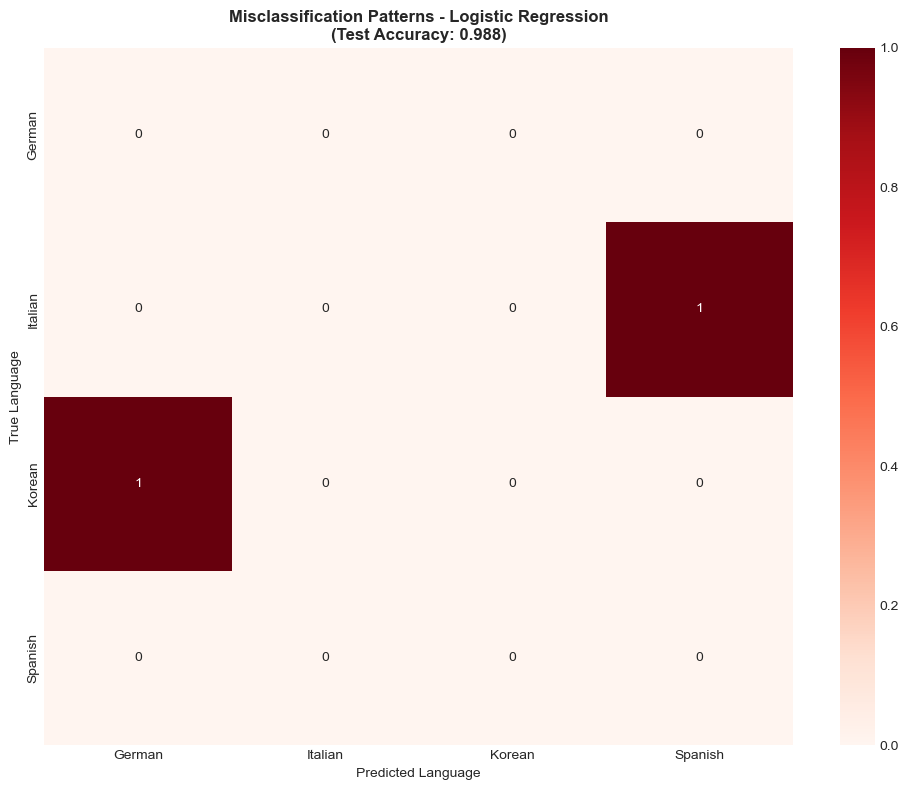

In [84]:
# Analyze misclassifications for best model
best_model_name = top_3_models[0]
y_pred_best = results[best_model_name]['y_pred']

# Create misclassification analysis
misclassified_mask = y_pred_best != y_test_clean
misclassified_indices = np.where(misclassified_mask)[0]

if len(misclassified_indices) > 0:
    # Get the actual test samples that were misclassified
    # Get the original test samples dataframe
    test_samples = original_features_df.iloc[test_indices].reset_index(drop=True)
    
    # Now get misclassified samples
    misclassified_samples = test_samples.iloc[misclassified_indices]
    
    misclassified_df = pd.DataFrame({
        'true_language': language_le.inverse_transform(y_test_clean[misclassified_mask]),
        'predicted_language': language_le.inverse_transform(y_pred_best[misclassified_mask]),
        'filename': misclassified_samples['filename'].values,
        'speaker_id': misclassified_samples['speaker_id'].values,
        'gender': misclassified_samples['gender'].values
    })
    
    print(f"\n{'='*60}")
    print(f"MISCLASSIFICATION ANALYSIS: {best_model_name}")
    print('='*60)
    print(f"Total misclassifications: {misclassified_mask.sum()} / {len(y_test_clean)}")
    print(f"Overall accuracy: {1 - misclassified_mask.mean():.3f}")
    
    # Analyze by language
    print(f"\nMisclassifications by true language:")
    mis_by_language = misclassified_df['true_language'].value_counts()
    for lang, count in mis_by_language.items():
        total_lang = (y_test_clean == language_le.transform([lang])[0]).sum()
        print(f"  {lang}: {count}/{total_lang} ({count/total_lang*100:.1f}%)")
    
    # Analyze common confusion pairs
    print(f"\nMost common confusion pairs:")
    confusion_pairs = misclassified_df.groupby(['true_language', 'predicted_language']).size()
    for (true, pred), count in confusion_pairs.nlargest(5).items():
        print(f"  {true} → {pred}: {count} cases")
    
    # Visualize misclassification patterns
    plt.figure(figsize=(10, 8))
    misclassification_matrix = pd.crosstab(
        misclassified_df['true_language'],
        misclassified_df['predicted_language']
    )
    # Add all languages (even if no misclassifications)
    for lang in language_le.classes_:
        if lang not in misclassification_matrix.index:
            misclassification_matrix.loc[lang] = 0
        if lang not in misclassification_matrix.columns:
            misclassification_matrix[lang] = 0
    
    misclassification_matrix = misclassification_matrix.reindex(
        index=language_le.classes_, columns=language_le.classes_
    ).fillna(0)
    
    sns.heatmap(misclassification_matrix, annot=True, fmt='d', cmap='Reds',
                xticklabels=language_le.classes_, yticklabels=language_le.classes_)
    plt.title(f'Misclassification Patterns - {best_model_name}\n(Test Accuracy: {metrics_df.loc[best_model_name, "Test Accuracy"]:.3f})', 
              fontweight='bold')
    plt.xlabel('Predicted Language')
    plt.ylabel('True Language')
    plt.tight_layout()
    plt.savefig('./Classification/misclassification_patterns_leakage_free.png', dpi=300, bbox_inches='tight')
    plt.show()
    
else:
    print(f"\nPERFECT CLASSIFICATION for {best_model_name}!")


In [85]:
def evaluate_multiple_splits(model, X_full, y_full, speaker_full, n_splits=5):
    """Evaluate model with multiple random speaker-independent splits"""
    accuracies = []
    
    for seed in range(42, 42 + n_splits):
        # Create new split
        X_tr, X_te, y_tr, y_te, _, _ = create_speaker_independent_split(
            X_full, y_full, speaker_full, test_size=0.2, random_state=seed
        )
        
        # Scale features
        scaler_split = StandardScaler()
        X_tr_scaled = scaler_split.fit_transform(X_tr)
        X_te_scaled = scaler_split.transform(X_te)
        
        # Apply PCA
        pca_split = PCA(n_components=0.95)
        X_tr_pca = pca_split.fit_transform(X_tr_scaled)
        X_te_pca = pca_split.transform(X_te_scaled)
        
        # Train and evaluate
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_tr_pca, y_tr)
        accuracy = model_clone.score(X_te_pca, y_te)
        accuracies.append(accuracy)
    
    return accuracies

# Test with best model
best_model = results[best_model_name]['model']
multiple_split_accuracies = evaluate_multiple_splits(
    best_model, X, y_encoded, speaker_encoded, n_splits=5
)

print(f"\n{best_model_name} performance across 5 different splits:")
for i, acc in enumerate(multiple_split_accuracies, 1):
    print(f"  Split {i}: {acc:.3f}")

print(f"\nMean accuracy across splits: {np.mean(multiple_split_accuracies):.3f}")
print(f"Std deviation across splits: {np.std(multiple_split_accuracies):.3f}")



Logistic Regression performance across 5 different splits:
  Split 1: 0.988
  Split 2: 0.970
  Split 3: 1.000
  Split 4: 1.000
  Split 5: 0.979

Mean accuracy across splits: 0.988
Std deviation across splits: 0.012


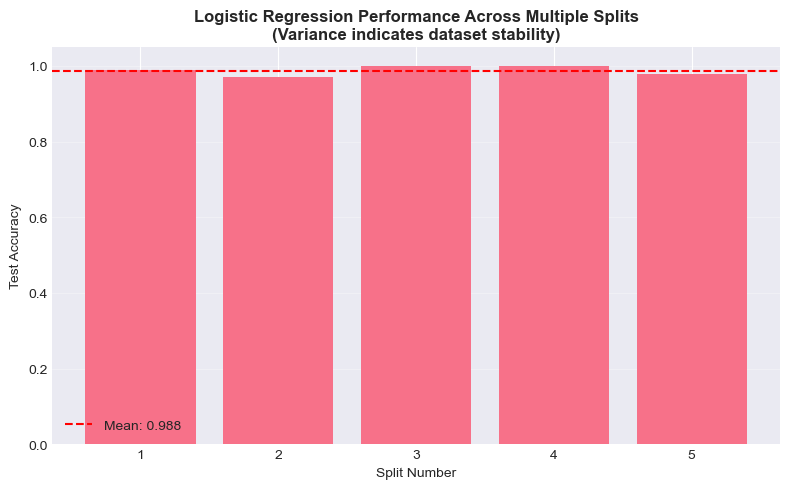

In [86]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), multiple_split_accuracies)
plt.axhline(y=np.mean(multiple_split_accuracies), color='r', linestyle='--', 
           label=f'Mean: {np.mean(multiple_split_accuracies):.3f}')
plt.xlabel('Split Number')
plt.ylabel('Test Accuracy')
plt.title(f'{best_model_name} Performance Across Multiple Splits\n(Variance indicates dataset stability)', 
          fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('./Classification/multiple_splits_validation.png', dpi=300, bbox_inches='tight')
plt.show()

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
💾 Save Models and Results
</div>

In [87]:
output_dir = './Classification_Results'
os.makedirs(output_dir, exist_ok=True)

# Save trained models
print(f"\nSaving models and results to {output_dir}/")
for name in results.keys():
    if 'model' in results[name]:
        model_filename = f'{output_dir}/model_{name.replace(" ", "_").lower()}.pkl'
        joblib.dump(results[name]['model'], model_filename)
        print(f"  Saved: {model_filename}")

# Save scaler, PCA, and label encoders
joblib.dump(scaler, f'{output_dir}/scaler.pkl')
joblib.dump(pca, f'{output_dir}/pca.pkl')
joblib.dump(language_le, f'{output_dir}/language_label_encoder.pkl')
joblib.dump(gender_le, f'{output_dir}/gender_label_encoder.pkl')
joblib.dump(speaker_le, f'{output_dir}/speaker_label_encoder.pkl')

# Save metrics
metrics_df.to_csv(f'{output_dir}/classification_metrics.csv')

# Save detailed results with timestamp
detailed_results = {
    'timestamp': datetime.now().isoformat(),
    'best_model': best_model_name,
    'best_accuracy': float(metrics_df.loc[best_model_name, 'Test Accuracy']),
    'multiple_split_mean': float(np.mean(multiple_split_accuracies)),
    'multiple_split_std': float(np.std(multiple_split_accuracies)),
    'model_performance': {}
}

for name in results.keys():
    if 'y_pred' in results[name]:
        detailed_results['model_performance'][name] = {
            'test_predictions': results[name]['y_pred'].tolist(),
            'test_accuracy': float(accuracy_score(y_test_clean, results[name]['y_pred'])),
            'train_accuracy': float(accuracy_score(y_train_aug, results[name]['y_pred_train'])),
            'cv_mean': float(results[name]['cv_mean']),
            'cv_std': float(results[name]['cv_std'])
        }

with open(f'{output_dir}/classification_results.json', 'w') as f:
    json.dump(detailed_results, f, indent=2)



Saving models and results to ./Classification_Results/
  Saved: ./Classification_Results/model_k-nearest_neighbors.pkl
  Saved: ./Classification_Results/model_support_vector_machine.pkl
  Saved: ./Classification_Results/model_random_forest.pkl
  Saved: ./Classification_Results/model_multi-layer_perceptron.pkl
  Saved: ./Classification_Results/model_decision_tree.pkl
  Saved: ./Classification_Results/model_logistic_regression.pkl
  Saved: ./Classification_Results/model_naive_bayes.pkl
